In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn  as sns
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.dates as mdates


In [2]:
with open("../data/ostatni_kanal.txt", "r", encoding="utf-8") as f:
    channel_name = f.read().strip()

#channel_name = "KanalZero"
file_path = f"../data/processed/processed_{channel_name}_videos_info.csv"
channel_info= pd.read_csv(file_path)

duration_time = pd.to_timedelta(channel_info['duration'])
channel_info['duration_minutes'] = (duration_time.dt.total_seconds() /60).round(2)
print("Analiza kanału: ")
print(channel_name)

Analiza kanału: 
Patec


In [3]:
category_map = {
    "1": "Film & Animation",
    "2": "Autos & Vehicles",
    "10": "Music",
    "15": "Pets & Animals",
    "17": "Sports",
    "18": "Short Movies",
    "19": "Travel & Events",
    "20": "Gaming",
    "21": "Videoblogging",
    "22": "People & Blogs",
    "23": "Comedy",
    "24": "Entertainment",
    "25": "News & Politics",
    "26": "Howto & Style",
    "27": "Education",
    "28": "Science & Technology",
    "29": "Nonprofits & Activism",
    "30": "Movies",
    "31": "Anime/Animation",
    "32": "Action/Adventure",
    "33": "Classics",
    "34": "Comedy",
    "35": "Documentary",
    "36": "Drama",
    "37": "Family",
    "38": "Foreign",
    "39": "Horror",
    "40": "Sci-Fi/Fantasy",
    "41": "Thriller",
    "42": "Shorts",
    "43": "Shows",
    "44": "Trailers"
}

In [4]:
df_clean = channel_info.copy()

df_clean['category_id'] = df_clean['category_id'].astype(str).map(category_map).fillna("Inne")

df_clean['published_at'] = pd.to_datetime(df_clean['published_at']).dt.strftime('%Y-%m-%d')

df_final = df_clean[[
    'channel_name', 'title', 'published_at', 
    'view_count', 'like_count', 'comment_count', 
    'category_id', 'duration_minutes', 'clickbait_score', 'clickbait_level', 'engagement_rate_%'
]]

df_final.columns = [
    'Nazwa Kanału', 'Tytuł Filmu', 'Data Publikacji', 
    'Liczba Wyświetleń', 'Liczba Polubień', 'Liczba Komentarzy', 
    'Kategoria', 'Czas trwania (min)', 'Wynik Clickbait', 'Poziom Clickbait', 'Współczynnik Zaangażowania (%)'
]
df_final.head()

,Nazwa Kanału,Tytuł Filmu,Data Publikacji,Liczba Wyświetleń,Liczba Polubień,Liczba Komentarzy,Kategoria,Czas trwania (min),Wynik Clickbait,Poziom Clickbait,Współczynnik Zaangażowania (%)
0,Patec,ZOSTAŁEM KASKADEREM,2026-06-06,6984,652,28,Entertainment,31.57,2,1. Rzetelny / Neutralny,9.34
1,Patec,TEN SPORT SERIO ISTNIEJE!,2026-05-30,309141,9162,152,Entertainment,42.73,3,2. Lekki marketing newsowy,2.96
2,Patec,schabowy za 112 zł? :O,2026-05-23,368564,10643,234,Entertainment,33.50,2,1. Rzetelny / Neutralny,2.89
3,Patec,TA WYSPA JEST ODCIĘTA OD ŚWIATA,2026-05-20,564721,15200,189,Entertainment,32.18,2,1. Rzetelny / Neutralny,2.69
4,Patec,CIEMNA STRONA PODRÓŻOWANIA (zostałem oszukany),2026-05-14,749780,17941,466,Entertainment,29.33,3,2. Lekki marketing newsowy,2.39


## Analiza rozwoju kanału: Wyświetlenia, Polubienia, Komentarze, Długość trwania filmiku

Zestawienie trzech wykresów umożliwia sprawdzenie, czy wysoka liczba wyświetleń przekłada się proporcjonalnie na liczbę polubień i komentarzy. Jeśli piki na wykresie wyświetleń nie znajdują odzwierciedlenia w pozostałych kategoriach, może to sugerować materiały o charakterze czysto informacyjnym lub o niskiej zdolności do wywoływania dyskusji. W przeciwieństwie do skupisk punktów na wykresie komentarzy, które jasno pozwalają zidentyfikować tematy, które angażują widownię.

Text(0.5, 1.05, 'Analiza kanału: Patec')

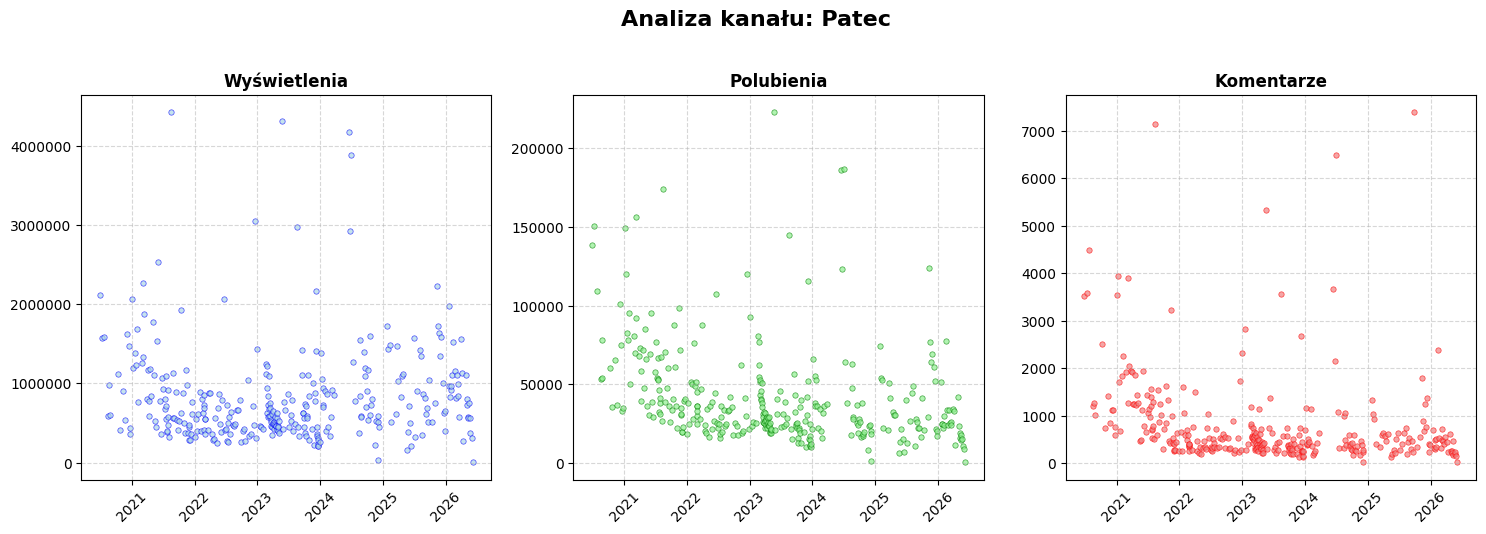

In [5]:

channel_info['published_at'] = pd.to_datetime(channel_info['published_at'])
channel_info = channel_info.sort_values('published_at')

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

metrics = [
    ('view_count', 'Wyświetlenia', 'lightblue', 'blue'),
    ('like_count', 'Polubienia', 'lightgreen', 'green'),
    ('comment_count', 'Komentarze', 'lightcoral', 'red')
]

for i, (col, title, color, edge) in enumerate(metrics):
    axes[i].scatter(channel_info['published_at'], channel_info[col], 
                    alpha=0.7, s=15, color=color, edgecolor=edge, linewidth=0.5)
    
    axes[i].set_title(title, fontsize=12, fontweight='bold')
    axes[i].ticklabel_format(style='plain', axis='y')
    axes[i].grid(True, linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=45)

fig.suptitle(f'Analiza kanału: {channel_name}', fontsize=16, fontweight='bold', y=1.05)



## Histogram rozkładu długości filmów pozwalający ocenić strategię kanału

Rozkład gdzie występuje kilka szczytów Wskazuje na świadome zarządzanie różnymi formatami treści. Jeśli wykres posiada odrębne skupiska (np. jedno przy 5-10 minutach, a drugie przy 60+ minutach), oznacza to, że kanał równolegle rozwija szybkie formy wideo oraz długie wywiady. Jeśli histogram jest wyraźnie skupiony w jednym przedziale, kanał utrzymuje jeden, stały format produkcyjny.

Wykres punktowy uzupełnia tę analizę, pokazując chronologiczną ewolucję długości materiałów, co pozwala zweryfikować, czy twórca konsekwentnie trzyma się wypracowanego standardu, czy też w czasie eksperymentuje ze zmianą formatów wideo.

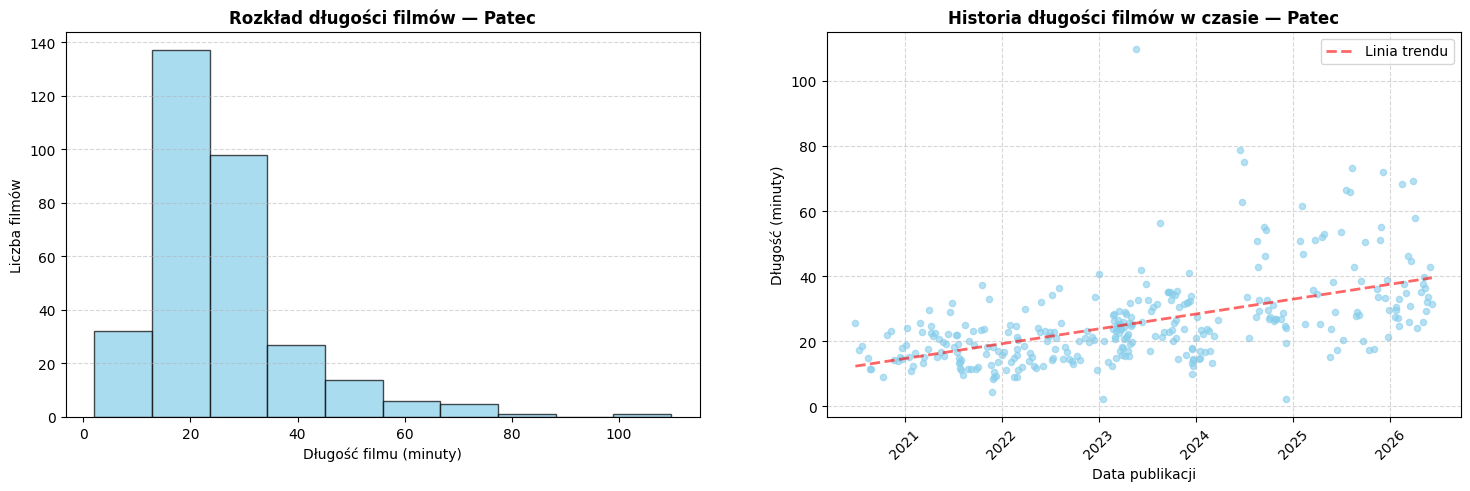

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

ax1.hist(channel_info['duration_minutes'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_title(f'Rozkład długości filmów — {channel_name}', fontsize=12, fontweight='bold')
ax1.set_xlabel('Długość filmu (minuty)', fontsize=10)
ax1.set_ylabel('Liczba filmów', fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

ax2.scatter(channel_info['published_at'], channel_info['duration_minutes'], color='skyblue', marker='o', alpha=0.6, s=20)
x_vals = mdates.date2num(channel_info['published_at'])
y_vals = channel_info['duration_minutes']
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
ax2.plot(channel_info['published_at'], p(x_vals), color='red',alpha=0.6, linestyle='--', linewidth=2, label='Linia trendu')
ax2.set_title(f'Historia długości filmów w czasie — {channel_name}', fontsize=12, fontweight='bold')
ax2.set_xlabel('Data publikacji', fontsize=10)
ax2.set_ylabel('Długość (minuty)', fontsize=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

## Macierz współczynników korelacji Pearsona

Text(0.5, 1.0, 'Macierz korelacji cech: Patec')

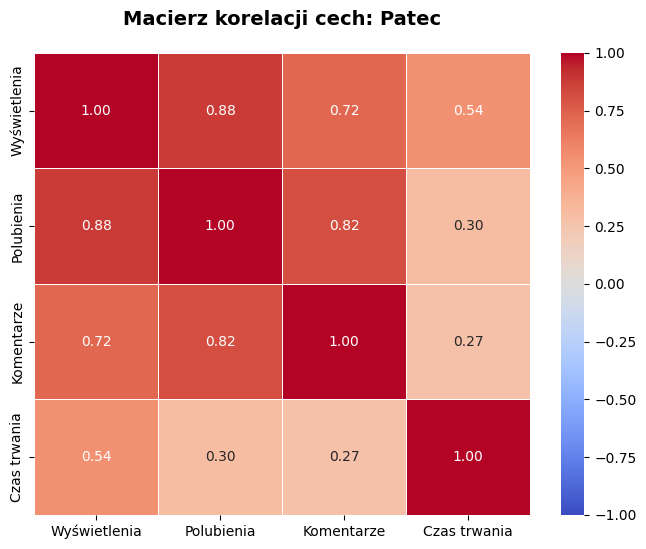

In [7]:

df_corr = channel_info[['view_count', 'like_count', 'comment_count', 'duration_minutes']].rename(columns={
    'view_count': 'Wyświetlenia',
    'like_count': 'Polubienia',
    'comment_count': 'Komentarze',
    'duration_minutes': 'Czas trwania'
})

korelacja = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(korelacja, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=0.5)
plt.title(f'Macierz korelacji cech: {channel_name}', fontsize=14, fontweight='bold', pad=20)


## Statystyczne podsumowanie kluczowych metryk kanału
Prezentuje średnie wartości, zmienność zasięgów oraz charakterystykę długości publikowanych materiałów.

In [8]:

kolumny_analizy = ['duration_minutes', 'view_count', 'like_count', 'comment_count']

stats = channel_info[kolumny_analizy].describe().rename(columns={
    'duration_minutes': 'Czas trwania (min)',
    'view_count': 'Wyświetlenia',
    'like_count': 'Polubienia',
    'comment_count': 'Komentarze'
})

formatowanie = {
    'Wyświetlenia': '{:,.0f}',
    'Polubienia': '{:,.0f}',
    'Czas trwania (min)': '{:,.2f}',
    'Komentarze': '{:,.0f}'
}

stats.style.format(formatowanie).set_caption(f"Statystyki kanału: {channel_name}")

,Czas trwania (min),Wyświetlenia,Polubienia,Komentarze
count,321.00,321,321,321
mean,25.75,"823,906","41,422",792
std,13.74,"615,547","31,489",964
min,2.08,"6,984",652,22
25%,16.60,"450,981","22,459",312
50%,23.05,"630,391","31,398",477
75%,30.98,"992,938","50,667",790
max,109.73,"4,425,408","222,863","7,393"


## Analiza clickbaitu

## Wykres regresji (Wpływ Clickbaitu na zasięg)

Wykres ten obrazuje relację między atrakcyjnością tytułu a liczbą wyświetleń, wskazując czy bardziej chwytliwe nagłówki realnie przekładają się na większy zasięg oraz sprawdza czy strategia obrana przez kanał jest skuteczna pod względem wyboru tytułu 

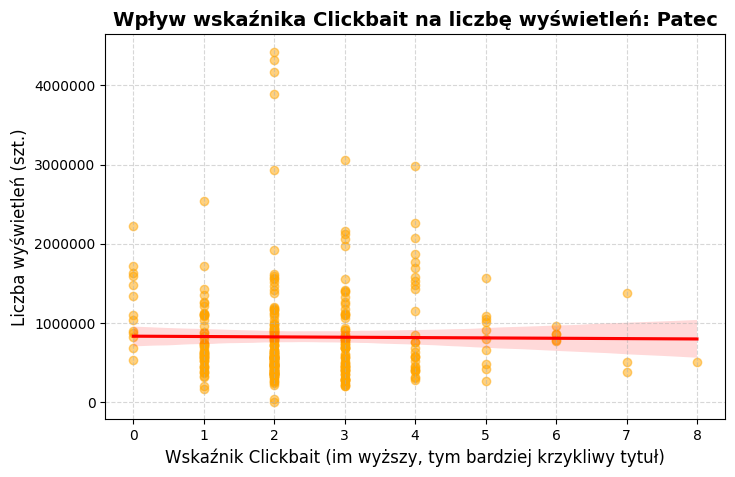

In [9]:

plt.figure(figsize=(8, 5))
sns.regplot(data=channel_info, x="clickbait_score", y="view_count", 
            scatter_kws={'alpha':0.5, 'color':'orange'}, line_kws={'color':'red'})
plt.title(f'Wpływ wskaźnika Clickbait na liczbę wyświetleń: {channel_name}', fontsize=14, fontweight='bold')
plt.xlabel('Wskaźnik Clickbait (im wyższy, tym bardziej krzykliwy tytuł)', fontsize=12)
plt.ylabel('Liczba wyświetleń (szt.)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ticklabel_format(style='plain', axis='y')


## Wykres pudełkowy (Clickbait a zaangażowanie)

Zestawienie to prezentuje zależność między poziomem clickbaitu a rzeczywistym zaangażowaniem widzów, mierząc jakość interakcji po kliknięciu, sprawdza czy clickbaitowe tytuły zachęcają do dyskusji.

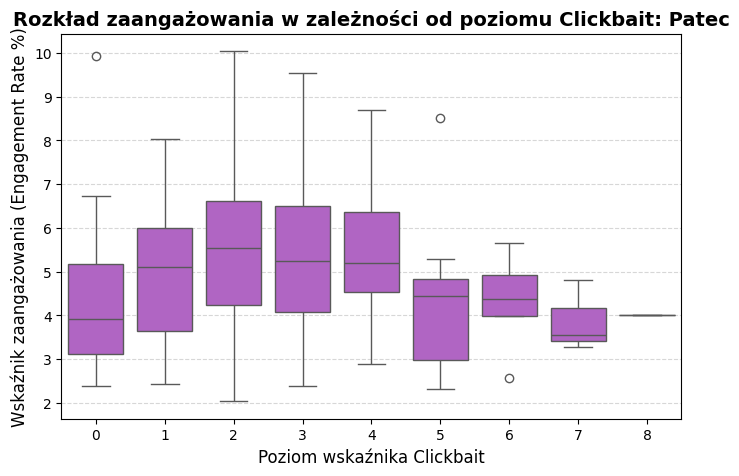

In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=channel_info, x="clickbait_score", y="engagement_rate_%", color="mediumorchid")
plt.title(f'Rozkład zaangażowania w zależności od poziomu Clickbait: {channel_name}', fontsize=14, fontweight='bold')
plt.xlabel('Poziom wskaźnika Clickbait', fontsize=12)
plt.ylabel('Wskaźnik zaangażowania (Engagement Rate %)', fontsize=12)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)


## Tabela słów kluczowych (Analiza semantyczna)

Tabela przedstawia porównanie fraz najczęściej występujących w najpopularniejszych oraz najmniej docenianych filmach na kanale, pomaga zidentyfikować „język sukcesu” oraz eliminować zwroty, które statystycznie nie budzą zainteresowania widowni.

In [11]:
top = channel_info[channel_info["view_count"] >= channel_info["view_count"].quantile(0.8)]
bottom = channel_info[channel_info["view_count"] <= channel_info["view_count"].quantile(0.2)]

stopwords_pl = ["i", "a", "oraz", "że", "to", "na", "w", "z", "do", "od", "po", "jak", "czy", "się", "nie", "jest", "dla", "co", "o", "za"]

def get_ranking(df_subset):
    vec = TfidfVectorizer(ngram_range=(1, 2), stop_words=stopwords_pl)
    X = vec.fit_transform(df_subset["title"].astype(str))
    scores = X.sum(axis=0).A1
    return pd.DataFrame({"word": vec.get_feature_names_out(), "score": scores}).sort_values("score", ascending=False)

r_top, r_bot = get_ranking(top), get_ranking(bottom)
tabela = pd.DataFrame({
    'Lp.': range(1, 11),
    'Słowa (Top 20%)': r_top.head(10)['word'].values,
    'Wynik (Top)': r_top.head(10)['score'].round(2).values,
    'Słowa (Bottom 20%)': r_bot.head(10)['word'].values,
    'Wynik (Bottom)': r_bot.head(10)['score'].round(2).values
})
display(tabela.style.hide(axis='index'))

Lp.,Słowa (Top 20%),Wynik (Top),Słowa (Bottom 20%),Wynik (Bottom)
1,wojna,2.240000,zostałem,1.420000
2,kuchenna,2.130000,świata,1.310000
3,kuchenna wojna,1.920000,ten,1.070000
4,mount everest,1.610000,trening,1.070000
5,mount,1.610000,sport,1.000000
6,everest,1.610000,amsterdam,1.000000
7,80ddś,1.210000,ironmanie,1.000000
8,owg,1.210000,pech,1.000000
9,odwiedziłem,1.200000,24h,0.890000
10,dni,1.190000,wojna,0.850000
